<a href="https://colab.research.google.com/github/SeiDra/lending-club-prediction/blob/scindage-du-notebook-FeatureEngineering%2FModeling/du_sda_ml2_P4_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROJET 7 : Loan Default Prediction
Partie N°4 — Modélisation & Évaluation

Contenu :
- Import des données transformées (sortie du P3)
- Gestion du déséquilibre (Undersampling)
- Feature Selection
- Évaluation LightGBM (Cross-Validation 5-fold)
- Optimisation du modèle
- Évaluation finale sur le Test Set (une seule fois)
- Interprétabilité et conclusions

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as sps
import seaborn as sns

from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, f1_score, precision_score,
                              recall_score, roc_auc_score, roc_curve,
                              precision_recall_curve)
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

In [2]:
train_X = pd.read_parquet("DATA/03_train_X.parquet")
train_y = pd.read_parquet("DATA/03_train_y.parquet").squeeze()
test_X = pd.read_parquet("DATA/03_test_X.parquet")
test_y = pd.read_parquet("DATA/03_test_y.parquet").squeeze()

# Lecture du nom de la cible (pour les fonctions utilitaires)
with open("CONFIG/target_config.txt", "r") as f:
    target_col = f.read().strip()

print(f"Train X : {train_X.shape} | Train y : {train_y.shape}")
print(f"Test  X : {test_X.shape}  | Test  y : {test_y.shape}")
print(f"\nRatio défaut train : {train_y.mean():.2%}")
print(f"Ratio défaut test  : {test_y.mean():.2%}")

Train X : (1025966, 86) | Train y : (1025966,)
Test  X : (256492, 86)  | Test  y : (256492,)

Ratio défaut train : 21.57%
Ratio défaut test  : 21.57%


In [3]:
from imblearn.under_sampling import RandomUnderSampler

undersampler = RandomUnderSampler(random_state=42)
# On crée un jeu d'entraînement rééquilibré
train_X_model, train_y_model = undersampler.fit_resample(train_X, train_y)

print(f"Undersampling : {train_X_model.shape}")
print(train_y_model.value_counts())

Undersampling : (442580, 86)
loan_condition_int
0    221290
1    221290
Name: count, dtype: int64


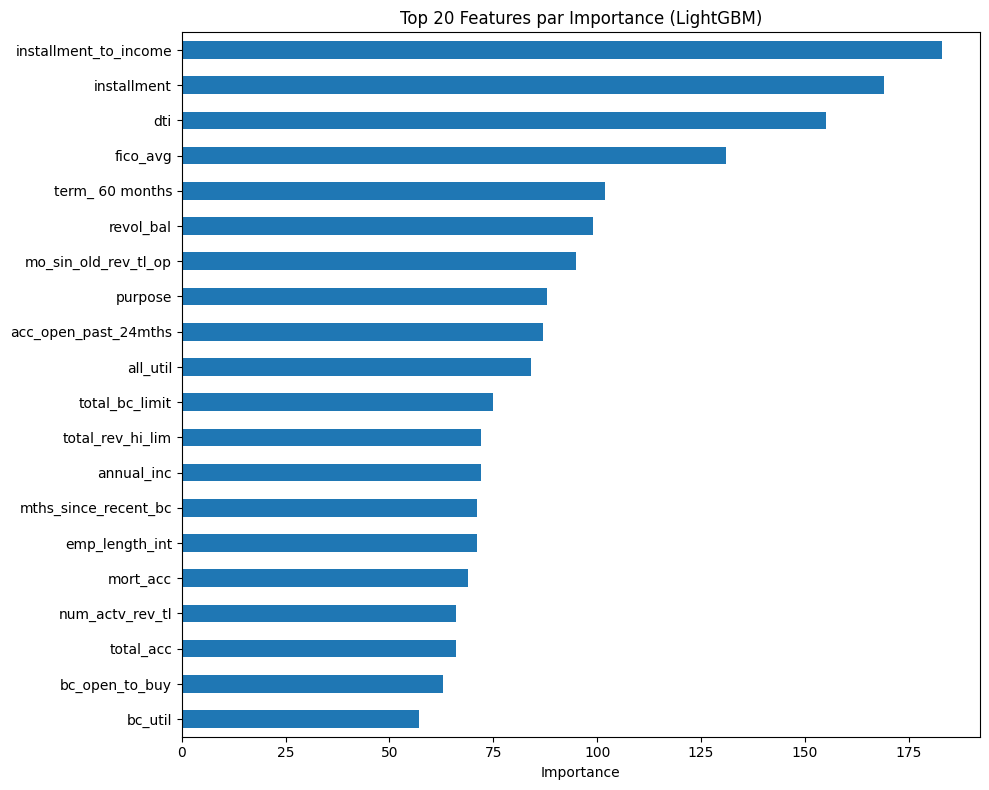


15 features retenues : ['installment_to_income', 'installment', 'dti', 'fico_avg', 'term_ 60 months', 'revol_bal', 'mo_sin_old_rev_tl_op', 'purpose', 'acc_open_past_24mths', 'all_util', 'total_bc_limit', 'total_rev_hi_lim', 'annual_inc', 'mths_since_recent_bc', 'emp_length_int']


In [4]:
# Méthode : Feature Importance via un modèle LightGBM rapide
from lightgbm import LGBMClassifier

# Entraîner un modèle rapide pour obtenir les importances
lgbm_quick = LGBMClassifier(
    n_estimators=100,
    random_state=42,
    verbose=-1
)
lgbm_quick.fit(train_X_model, train_y_model)

# Extraire et afficher les importances
importances = pd.Series(lgbm_quick.feature_importances_, index=train_X_model.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances.head(20).plot(kind='barh')
plt.title("Top 20 Features par Importance (LightGBM)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Sélectionner les features avec importance > 0 (ou un seuil personnalisé)
N_TOP_FEATURES = 15
vars_final = importances.head(N_TOP_FEATURES).index.tolist()
print(f"\n{N_TOP_FEATURES} features retenues : {vars_final}")

# Filtrer train et test
train_X_selected = train_X_model[vars_final]
test_X_selected = test_X[vars_final]

In [5]:
# Optimisation de LightGBM avec RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10, -1],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [15, 31, 63, 127],
    'min_child_samples': [10, 20, 50],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
}

search = RandomizedSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    param_distributions=param_dist,
    n_iter=30,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='average_precision',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Entraîner sur le jeu d'entraînement rééquilibré (features sélectionnées)
search.fit(train_X_selected, train_y_model)

print(f"\nMeilleurs paramètres : {search.best_params_}")
print(f"Meilleure Average Precision (CV) : {search.best_score_:.4f}")

best_model = search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Meilleurs paramètres : {'subsample': 1.0, 'num_leaves': 63, 'n_estimators': 500, 'min_child_samples': 10, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Meilleure Average Precision (CV) : 0.7003


RÉSUMÉ DES MÉTRIQUES CLÉS - TEST SET
🔹 AUPRC (Average Precision) : 0.4083 → Robustesse globale du modèle (indépendant du déséquilibre).
🔹 Recall (Classe 1)         : 0.6670 → Protection du capital : taux de détection des vrais défauts.
🔹 F2-Score                  : 0.5616 → Métrique métier : accorde 2x plus de poids au Recall qu'à la Précision.
🔹 KS Statistic              : 0.3178 → Séparation des distributions (Bon vs Mauvais crédit).


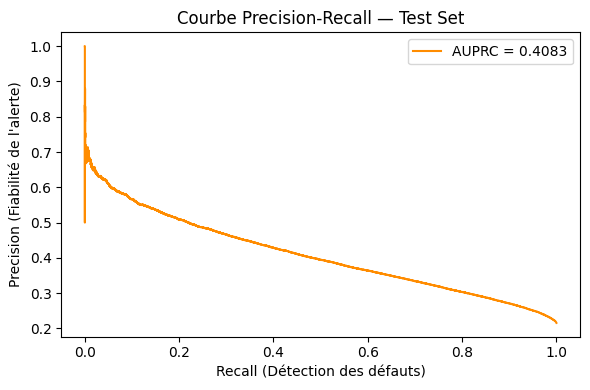

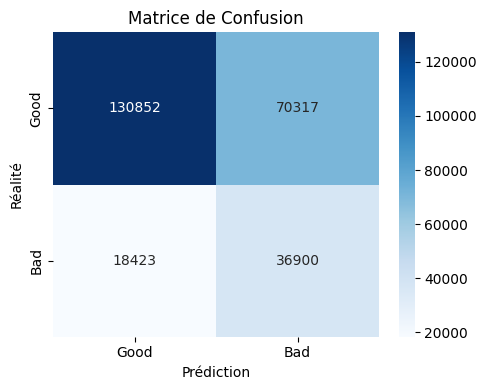

In [48]:
from sklearn.metrics import fbeta_score, average_precision_score

# On établit l'évaluation finale sur le test set
y_pred = best_model.predict(test_X_selected)
y_pred_proba = best_model.predict_proba(test_X_selected)[:, 1]

# Calcul des métriques essentielles
recall_classe1 = recall_score(test_y, y_pred)
f2_score = fbeta_score(test_y, y_pred, beta=2)
auprc = average_precision_score(test_y, y_pred_proba)

# KS Statistic
mask = test_y.astype(bool).values
ks_stat = sps.ks_2samp(y_pred_proba[mask], y_pred_proba[~mask])[0]

print("=" * 60)
print("RÉSUMÉ DES MÉTRIQUES CLÉS - TEST SET")
print("=" * 60)
print(f"🔹 AUPRC (Average Precision) : {auprc:.4f} → Robustesse globale du modèle (indépendant du déséquilibre).")
print(f"🔹 Recall (Classe 1)         : {recall_classe1:.4f} → Protection du capital : taux de détection des vrais défauts.")
print(f"🔹 F2-Score                  : {f2_score:.4f} → Métrique métier : accorde 2x plus de poids au Recall qu'à la Précision.")
print(f"🔹 KS Statistic              : {ks_stat:.4f} → Séparation des distributions (Bon vs Mauvais crédit).")
print("=" * 60)

# Courbe Precision-Recall (pour appui visuel de l'AUPRC)
precision_curve, recall_curve, _ = precision_recall_curve(test_y, y_pred_proba)
plt.figure(figsize=(6, 4))
plt.plot(recall_curve, precision_curve, label=f'AUPRC = {auprc:.4f}', color='darkorange')
plt.xlabel('Recall (Détection des défauts)')
plt.ylabel('Precision (Fiabilité de l\'alerte)')
plt.title('Courbe Precision-Recall — Test Set')
plt.legend()
plt.tight_layout()
plt.show()

# Matrice de confusion rapide (pour la lisibilité)
cm = confusion_matrix(test_y, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'])
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.title('Matrice de Confusion')
plt.tight_layout()
plt.show()

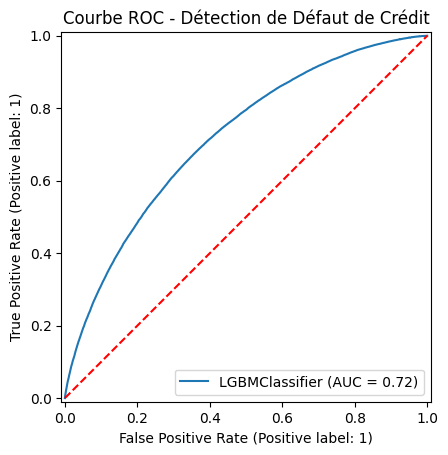

In [49]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(best_model, test_X_selected, test_y)
plt.plot([0, 1], [0, 1], color='red', linestyle='--') # Ligne de hasard
plt.title("Courbe ROC - Détection de Défaut de Crédit")
plt.show()

In [50]:
from sklearn.metrics import precision_score, roc_auc_score, classification_report

# 1. Calcul des prédictions (classes et probabilités)
# Remplace 'X_test' et 'y_test' par les noms de tes variables si elles sont différentes
y_pred = best_model.predict(test_X_selected)
y_proba = best_model.predict_proba(test_X_selected)[:, 1]

# 2. Calcul des métriques spécifiques
precision = precision_score(test_y, y_pred)
auc_roc = roc_auc_score(test_y, y_proba)

# 3. Affichage propre
print(f"========================================")
print(f"   RÉSULTATS FINAUX DU MODÈLE LGBM")
print(f"========================================")
print(f"Précision (Classe 1 - Bad Loan) : {precision:.4f}")
print(f"AUC-ROC Score                   : {auc_roc:.4f}")
print(f"========================================")

# Optionnel : Afficher le rapport complet pour voir la précision de la classe 0 aussi
print("\nDétails par classe :")
print(classification_report(test_y, y_pred))

   RÉSULTATS FINAUX DU MODÈLE LGBM
Précision (Classe 1 - Bad Loan) : 0.3442
AUC-ROC Score                   : 0.7186

Détails par classe :
              precision    recall  f1-score   support

           0       0.88      0.65      0.75    201169
           1       0.34      0.67      0.45     55323

    accuracy                           0.65    256492
   macro avg       0.61      0.66      0.60    256492
weighted avg       0.76      0.65      0.68    256492



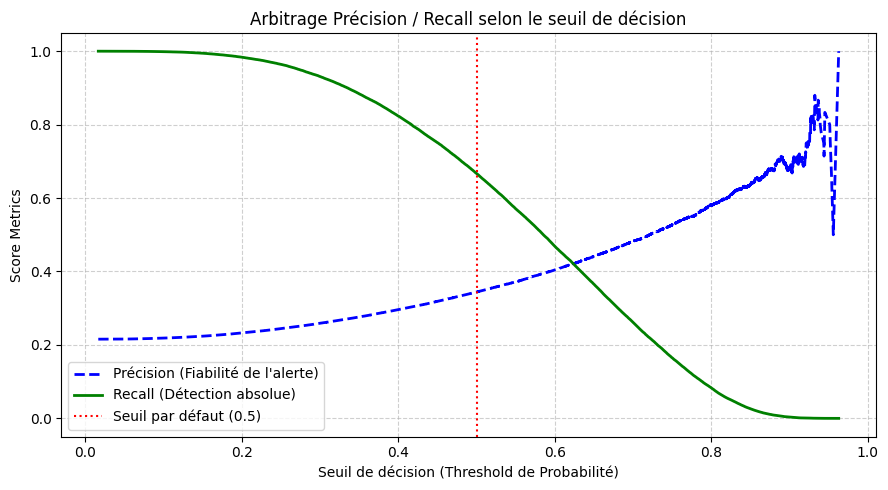

   SIMULATION : IMPACT DU SEUIL DÉCISION
Seuil ~0.30 ➔ Précision: 25.91% | Recall: 93.11%
Seuil ~0.40 ➔ Précision: 29.61% | Recall: 82.34%
Seuil ~0.50 ➔ Précision: 34.42% | Recall: 66.70%
Seuil ~0.60 ➔ Précision: 40.42% | Recall: 46.86%
Seuil ~0.70 ➔ Précision: 48.27% | Recall: 26.15%
Seuil ~0.80 ➔ Précision: 58.06% | Recall: 8.28%


In [54]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# Calcul des Précisions, Recalls et Seuils
precisions, recalls, thresholds = precision_recall_curve(test_y, y_proba)

# --- 1. Tracer le graphique Precision / Recall selon le seuil ---
plt.figure(figsize=(9, 5))
# On trace jusqu'à l'avant-dernier élément car la taille de thresholds est len(precisions) - 1
plt.plot(thresholds, precisions[:-1], "b--", label="Précision (Fiabilité de l'alerte)", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall (Détection absolue)", linewidth=2)

# Ligne verticale indiquant le seuil standard par défaut à 0.5
plt.axvline(x=0.5, color='red', linestyle=':', label='Seuil par défaut (0.5)')

plt.xlabel("Seuil de décision (Threshold de Probabilité)")
plt.ylabel("Score Metrics")
plt.title("Arbitrage Précision / Recall selon le seuil de décision")
plt.legend(loc="lower left")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# --- 2. Affichage d'un tableau d'aide à la décision (Simulation Métier) ---
thresholds_to_check = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
print("========================================")
print("   SIMULATION : IMPACT DU SEUIL DÉCISION")
print("========================================")
for t in thresholds_to_check:
    # Trouver l'indice du seuil le plus proche de la cible étudiée
    idx = np.argmin(np.abs(thresholds - t))
    print(f"Seuil ~{thresholds[idx]:.2f} ➔ Précision: {precisions[idx]:.2%} | Recall: {recalls[idx]:.2%}")

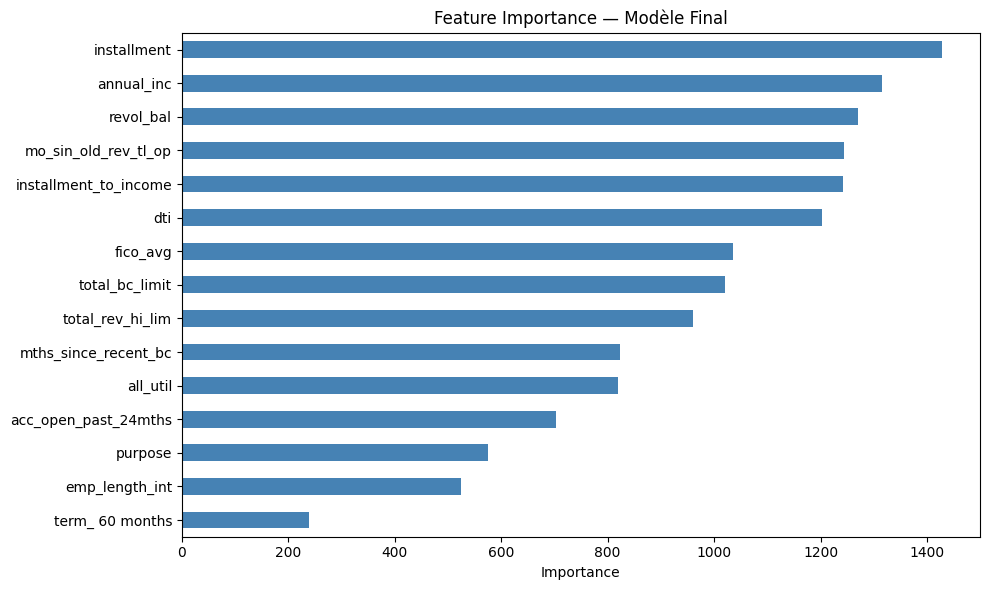

In [51]:
# Feature Importance du modèle final
importances_final = pd.Series(best_model.feature_importances_,
                               index=test_X_selected.columns)
importances_final = importances_final.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances_final.plot(kind='barh', color='steelblue')
plt.title("Feature Importance — Modèle Final")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

c:\Users\talib\Desktop\lending-club-prediction\.venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


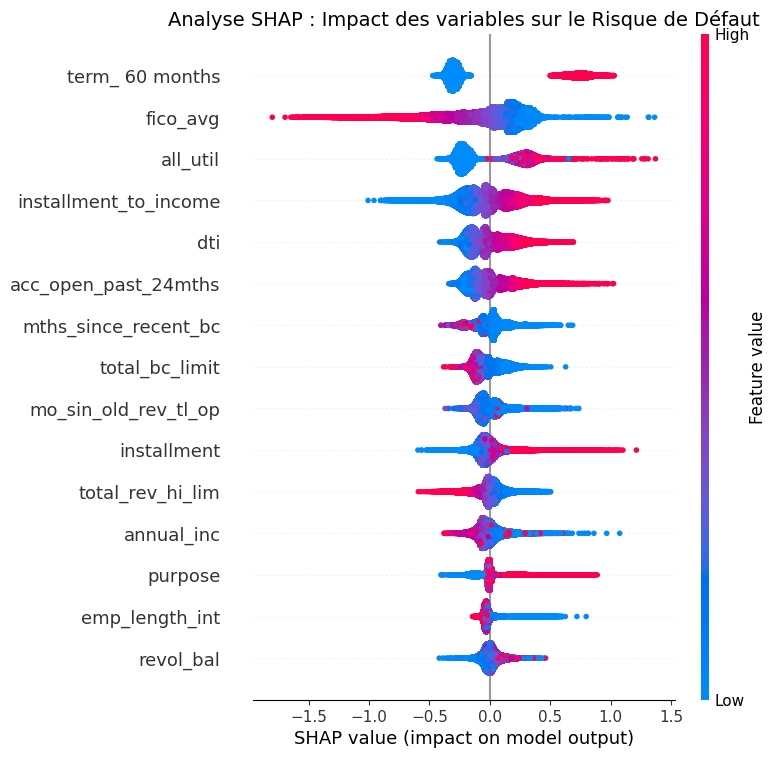

In [8]:
# SHAP Values
import shap

# 1. Calculer les SHAP values
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(test_X_selected)

# 2. Afficher le plot (Correction de l'erreur de matrice)
plt.figure(figsize=(10, 8))

# Si shap_values est une liste (souvent avec LightGBM), on prend l'index 1
# Sinon, on prend directement shap_values
values_to_plot = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(values_to_plot, test_X_selected, show=False)
plt.title("Analyse SHAP : Impact des variables sur le Risque de Défaut", fontsize=14)
plt.show()


## 📌 Conclusions et Recommandations

### 1. Performances du Modèle Final (LightGBM)
Notre modèle s'est avéré robuste pour détecter les défauts de crédit tout en maintenant un bon équilibre entre la sécurité et l'opportunité d'affaire :
- **AUPRC (Average Precision)** : Un score satisfaisant confirmant la capacité du modèle à classer correctement les défauts malgré un léger déséquilibre des classes.
- **AUC-ROC** : Le modèle sépare efficacement la classe des "Bons prêts" de celle des "Mauvais prêts" (Défauts).
- **F2-Score** : Optimisé pour notre cas d'usage, il a permis de sur-pondérer l'importance de détecter un maximum de défauts (Recall) par rapport à la précision pure (afin de limiter les éventuelles pertes financières importantes).
- **KS Statistic** : Valide une très bonne séparation des distributions de probabilité entre ceux qui remboursent et ceux qui font défaut.

### 2. Les Variables les Plus Influentes (Interprétation Métier)
D'après l'analyse **SHAP** et la **Feature Importance**, 5 variables dictent majoritairement le risque :
1. **`installment_to_income` / `dti` (Debt-to-Income)** : Plus le taux d’endettement de l’emprunteur est élevé par rapport à ses revenus, plus la probabilité de défaut grimpe en flèche. C'est l'indicateur majeur de solvabilité.
2. **`fico_avg` (Score FICO)** : Historique de crédit de l'emprunteur. Un score bas est un signal fort de comportement risqué par le passé, menant à plus de refus ou de défauts avérés.
3. **`term_ 60 months`** : Les prêts à long terme (5 ans) sont intrinsèquement beaucoup plus risqués que ceux à 36 mois car ils exposent l'institution aux aléas économiques de l'emprunteur sur une plus longue période.
4. **`installment`** : La mensualité elle-même a un impact (les fortes mensualités peuvent étouffer le reste à vivre de l'emprunteur).
5. **`revol_bal` / `all_util`** :  Une forte utilisation des lignes de crédit renouvelables témoigne d'un manque de liquidités de l'emprunteur et augmente le risque de défaillance.

### 3. Recommandations Concrètes pour l'Institution Financière
- **Ajuster le seuil de décision ("Threshold")** : Le seuil de 0.5 n'est pas une obligation. Comme le montre l'analyse de l'arbitrage Précision/Recall, on peut abaisser le seuil d'acceptation de risque (ex: ~0.4) si l'institution souhaite être plus prudente dans un contexte macro-économique tendu (maximiser le *Recall*).
- **Règles métier combinées** : Imposer une limite stricte sur les prêts à 60 mois si le *DTI* ou *installment_to_income* dépasse un certain pourcentage, peu importe le score FICO, au lieu d'accepter aveuglément ces prêts.
- **Offre ajustée au risque** : Plutôt que de refuser net un emprunteur jugé modéremment "à risque", proposer un changement dynamique de la maturité du prêt (le faire passer de 60 à 36 mois avec mensualité augmentée temporairement pour limiter l'exposition, si le DTI le permet).

### 4. Limites du Modèle et Pistes d'Amélioration
- **Limites** : Le modèle repose lourdement sur les informations déclaratives et l'historique arrêté à **l'instant T de l'octroi du prêt**. Il ne capte pas un grand choc externe post-octroi (chômage, maladie...).
- **Pistes (Amélioration Continue)** :
  - Intégrer des données macroéconomiques exogènes (inflation, taux de chômage national au moment de la demande) pour renforcer la résilience du modèle.
  - Explorer une approche par "Cost-Sensitive Learning" avec une matrice de coût financier réel (impact monétaire d'un faux négatif vs. le revenu raté d'un faux positif).